In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style='whitegrid')

df = pd.read_csv('../output/orders_clean.csv',
    parse_dates=['order_purchase_timestamp'])
items = pd.read_csv('../data/olist_order_items_dataset.csv')

print("Data siap:", df.shape)

Data siap: (110197, 18)


In [4]:
# Gabungkan orders dengan items untuk dapat total belanja
item_agg = (items.groupby('order_id')
            .agg(revenue=('price','sum'))
            .reset_index())

df_full = df.merge(item_agg, on='order_id', how='inner')

# Tanggal referensi = hari setelah tanggal order terakhir
# (simulasi "hari ini" dari perspektif dataset)
reference_date = df_full['order_purchase_timestamp'].max() \
                 + pd.Timedelta(days=1)

print("Tanggal referensi:", reference_date.date())

# Hitung RFM per customer_id
rfm = (df_full.groupby('customer_id')
       .agg(
           recency   = ('order_purchase_timestamp',
                        lambda x: (reference_date - x.max()).days),
           frequency = ('order_id', 'nunique'),
           monetary  = ('revenue', 'sum')
       )
       .reset_index())

print(f"\nJumlah pelanggan unik: {len(rfm):,}")
print("\nStatistik RFM:")
print(rfm[['recency','frequency','monetary']].describe().round(1))

Tanggal referensi: 2018-08-30

Jumlah pelanggan unik: 96,478

Statistik RFM:
       recency  frequency  monetary
count  96478.0    96478.0   96478.0
mean     240.1        1.0     173.8
std      152.8        0.0     569.0
min        1.0        1.0       0.8
25%      116.0        1.0      47.9
50%      221.0        1.0      89.9
75%      350.0        1.0     168.0
max      714.0        1.0  107520.0


K=2 | Inertia: 125,045 | Silhouette: 0.522
K=3 | Inertia: 85,058 | Silhouette: 0.524
K=4 | Inertia: 65,020 | Silhouette: 0.537
K=5 | Inertia: 49,259 | Silhouette: 0.475
K=6 | Inertia: 34,458 | Silhouette: 0.487
K=7 | Inertia: 27,121 | Silhouette: 0.497
K=8 | Inertia: 22,041 | Silhouette: 0.448
K=9 | Inertia: 18,463 | Silhouette: 0.455
K=10 | Inertia: 15,753 | Silhouette: 0.435


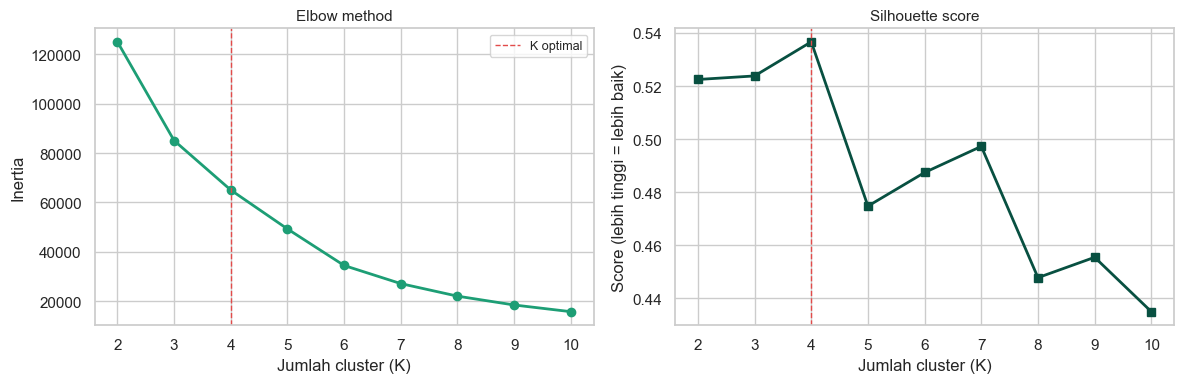

In [5]:
# Scaling dulu — K-Means sensitif terhadap skala
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['recency','frequency','monetary']])

# Coba K dari 2 sampai 10, catat inertia dan silhouette score
inertias    = []
silhouettes = []
K_range     = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(rfm_scaled, km.labels_))
    print(f"K={k} | Inertia: {km.inertia_:,.0f} | "
          f"Silhouette: {silhouettes[-1]:.3f}")

# Plot elbow + silhouette
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_range, inertias, marker='o', color='#1D9E75',
             linewidth=2, markersize=6)
axes[0].set_title('Elbow method', fontsize=11, fontweight='500')
axes[0].set_xlabel('Jumlah cluster (K)')
axes[0].set_ylabel('Inertia')
axes[0].axvline(4, color='#E24B4A', linestyle='--',
                linewidth=1, label='K optimal')
axes[0].legend(fontsize=9)

axes[1].plot(K_range, silhouettes, marker='s', color='#085041',
             linewidth=2, markersize=6)
axes[1].set_title('Silhouette score', fontsize=11, fontweight='500')
axes[1].set_xlabel('Jumlah cluster (K)')
axes[1].set_ylabel('Score (lebih tinggi = lebih baik)')
axes[1].axvline(4, color='#E24B4A', linestyle='--', linewidth=1)

plt.tight_layout()
plt.savefig('../output/11-elbow-silhouette.png', dpi=150)
plt.show()

In [6]:
# Latih K-Means dengan K=4
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['cluster'] = km_final.fit_predict(rfm_scaled)

# Profil tiap cluster — rata-rata RFM per segmen
profil = (rfm.groupby('cluster')
          .agg(
              recency   = ('recency',   'mean'),
              frequency = ('frequency', 'mean'),
              monetary  = ('monetary',  'mean'),
              jumlah    = ('customer_id','count')
          )
          .round(1))

print("Profil cluster:")
print(profil.to_string())

# Beri nama segmen berdasarkan karakteristik
# (sesuaikan dengan output profil yang kamu dapat)
def label_segmen(row):
    if row['recency'] < 150 and row['monetary'] > 200:
        return 'Champions'       # baru beli, nilai tinggi
    elif row['recency'] < 200 and row['monetary'] > 100:
        return 'Loyal'           # aktif, belanja cukup
    elif row['recency'] > 400:
        return 'Hibernating'     # lama tidak beli
    else:
        return 'At Risk'         # mulai jarang beli

rfm['segment'] = rfm.apply(label_segmen, axis=1)
print("\nDistribusi segmen:")
print(rfm['segment'].value_counts())

Profil cluster:
         recency  frequency  monetary  jumlah
cluster                                      
0          129.1        1.0     148.4   54745
1          388.2        1.0     149.4   41047
2          225.3        1.0   46624.4       6
3          235.2        1.0    3287.1     680

Distribusi segmen:
segment
At Risk        59619
Hibernating    17255
Loyal          13724
Champions       5880
Name: count, dtype: int64


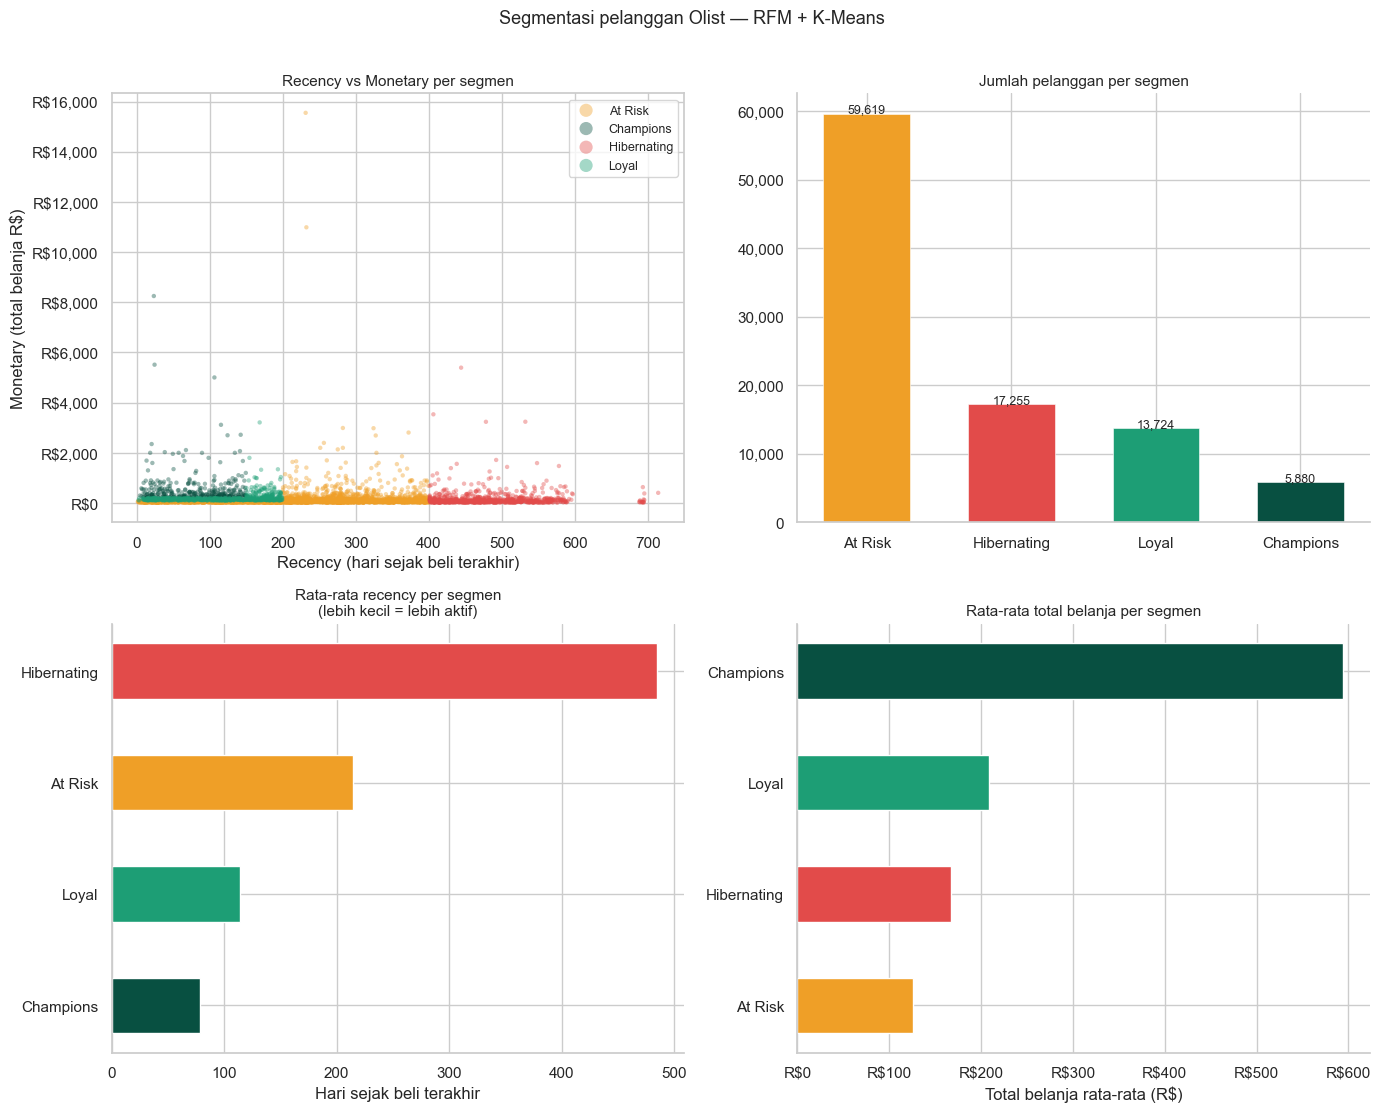

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
palette = {
    'Champions'  : '#085041',
    'Loyal'      : '#1D9E75',
    'At Risk'    : '#EF9F27',
    'Hibernating': '#E24B4A'
}

# ── Scatter: Recency vs Monetary ──────────────────────────────
sample = rfm.sample(5000, random_state=42)
for seg, grp in sample.groupby('segment'):
    axes[0,0].scatter(grp['recency'], grp['monetary'],
                      label=seg, color=palette[seg],
                      alpha=0.4, s=10, edgecolors='none')
axes[0,0].set_title('Recency vs Monetary per segmen',
                    fontsize=11, fontweight='500')
axes[0,0].set_xlabel('Recency (hari sejak beli terakhir)')
axes[0,0].set_ylabel('Monetary (total belanja R$)')
axes[0,0].legend(fontsize=9, markerscale=3)
axes[0,0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'R${x:,.0f}'))

# ── Bar: jumlah pelanggan per segmen ─────────────────────────
seg_count = rfm['segment'].value_counts()
bars = axes[0,1].bar(seg_count.index, seg_count.values,
                     color=[palette[s] for s in seg_count.index],
                     width=0.6, edgecolor='white', linewidth=0.4)
for bar, val in zip(bars, seg_count.values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 200,
                   f'{val:,}', ha='center', fontsize=9)
axes[0,1].set_title('Jumlah pelanggan per segmen',
                    fontsize=11, fontweight='500')
axes[0,1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
for sp in ['top','right']: axes[0,1].spines[sp].set_visible(False)

# ── Bar: rata-rata recency per segmen ─────────────────────────
seg_rec = rfm.groupby('segment')['recency'].mean().sort_values()
axes[1,0].barh(seg_rec.index, seg_rec.values,
               color=[palette[s] for s in seg_rec.index],
               height=0.5, edgecolor='white')
axes[1,0].set_title('Rata-rata recency per segmen\n(lebih kecil = lebih aktif)',
                    fontsize=11, fontweight='500')
axes[1,0].set_xlabel('Hari sejak beli terakhir')
for sp in ['top','right']: axes[1,0].spines[sp].set_visible(False)

# ── Bar: rata-rata monetary per segmen ────────────────────────
seg_mon = rfm.groupby('segment')['monetary'].mean().sort_values()
axes[1,1].barh(seg_mon.index, seg_mon.values,
               color=[palette[s] for s in seg_mon.index],
               height=0.5, edgecolor='white')
axes[1,1].set_title('Rata-rata total belanja per segmen',
                    fontsize=11, fontweight='500')
axes[1,1].set_xlabel('Total belanja rata-rata (R$)')
axes[1,1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'R${x:,.0f}'))
for sp in ['top','right']: axes[1,1].spines[sp].set_visible(False)

plt.suptitle('Segmentasi pelanggan Olist — RFM + K-Means',
             fontsize=13, fontweight='500', y=1.01)
plt.tight_layout()
plt.savefig('../output/12-rfm-segmentasi.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Simpan hasil segmentasi
rfm.to_csv('../output/rfm-segmentasi.csv', index=False)

# Ringkasan per segmen untuk laporan
ringkasan = (rfm.groupby('segment')
             .agg(
                 jumlah_pelanggan = ('customer_id','count'),
                 avg_recency      = ('recency','mean'),
                 avg_monetary     = ('monetary','mean'),
                 total_revenue    = ('monetary','sum')
             ).round(1))

ringkasan['pct_pelanggan'] = (
    ringkasan['jumlah_pelanggan'] /
    ringkasan['jumlah_pelanggan'].sum() * 100
).round(1)

print(ringkasan.to_string())

             jumlah_pelanggan  avg_recency  avg_monetary  total_revenue  pct_pelanggan
segment                                                                               
At Risk                 59619        214.3         126.3      7528515.9           61.8
Champions                5880         78.7         593.6      3490542.9            6.1
Hibernating             17255        484.8         167.1      2882700.2           17.9
Loyal                   13724        113.8         208.9      2867576.6           14.2
